In [3]:
from dotenv import load_dotenv
load_dotenv()

True

### 패키지 및 프레임워크 로딩

에이전트 기반 LLM 파이프라인 구현을 위한 주요 라이브러리 로딩

LangGraph를 중심으로 한 상태 기반 에이전트 구성을 위한 핵심 패키지 위주로 구성

In [4]:
import operator
from typing import Annotated, Optional, List
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import create_react_agent
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel
from typing import Literal
import functools
from langchain_community.tools import TavilySearchResults
from langchain.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables import RunnableConfig
from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore
import faiss
from langchain_core.prompts import SystemMessagePromptTemplate, HumanMessagePromptTemplate
import pandas as pd

import pickle
from tqdm import tqdm

### 크롤링 메시지 데이터 로드 / 임베딩 / 벡터스토어에 저장

In [8]:
df = pd.read_excel(r"0522_data.xlsx")
df.head()

,User,Message,User.1
0,린우,"평일 낮 책 읽기 양재동, 포이동, 양재천 카페거리 에 독서하기 편안한 카페...",린우
1,모래,샤로수길 청첩장모임하기 좋은 식당 있을까요? 인원은 10명 이상정도 될것같은데 괜...,모래
2,옷너무많앙,내일 2/14 노매뉴얼 플래그십스토어 가실분 내일 노매뉴얼 플래그십 스토어 프레젠...,옷너무많앙
3,SS,한일교류회를 할거예요! 저는 일본에서 온 93년생 남자입니다. 5월10일 신촌역...,SS
4,톨이,오늘 준코같이 갈사람 오늘 저녁 준코가서 같이 놀사람 전남자입니다,톨이


In [ ]:
# 임베딩 과정 생략 가능
embeddings_model = OpenAIEmbeddings(model = 'text-embedding-3-small')
db = FAISS(
    embedding_function=embeddings_model,
    index=faiss.IndexFlatL2(1536),
    docstore=InMemoryDocstore(),
    index_to_docstore_id={}
)

for i in range(len(df)):
    db.add_texts([df['Message'][i]], metadatas=[{'User': df['User'][i]}], ids=[i])
db.save_local('test_data')

In [18]:
data = '0522_data_updated'

In [10]:
gpt = ChatOpenAI(model_name="gpt-4o", temperature=0)
# claude = ChatAnthropic(model="claude-3-7-sonnet-20250219")

### 에이전트 상태 및 실패 로그 구조 정의

LangGraph 기반 에이전트 실행을 위해 공통 상태(State)와 실패 로그 구조 정의.
에이전트 간 상태 공유, 실행 흐름 제어, 실패 케이스 추적을 위한 필드들로 구성.

FailureLog
매칭 실패 상황에 대한 원인, 대상 쿼리, 후보 정보 및 신뢰도 기록용 구조.

AgentState
LangGraph에서 사용되는 단일 상태 객체로,
사용자 입력, 에이전트 간 메시지 히스토리, 매칭 결과, 검색 및 재구성 정보 등을 포함.
Annotated 필드를 활용하여 상태 누적 및 카운트 기반 제어 로직 구성.

In [11]:
class FailureLog(TypedDict):
    detail: str
    failed_query: str
    failed_matched_mesasge: str
    failed_matched_candidate: str
    certainty: int
    # candidate_list: Optional[List[str]]

class AgentState(TypedDict):
    input_message: str
    username: Optional[str] = "Guest"
    count: Annotated[int, operator.add, lambda count, _: count + 1]
    evaluation_count: int = 1

    hypernym: Optional[str]
    matching_target: Optional[str]

    matched_message: Optional[str | dict]
    matched_username: Optional[str | dict]
    certainty: Optional[int]

    messages: str
    last_agent: str
    next_agent: str

    analyzed_message: Optional[str]
    search_info: Optional[str]
    reformed_query: Optional[str] = None
    candidates: Optional[List[str]]

    selectors_history: List[BaseMessage]
    failure_log: List[Optional[FailureLog]]
    history: Annotated[List[BaseMessage], operator.add]

In [12]:
# 각 노드들에 대한 프롬프트 로드

def load_prompt(filepath: str) -> str:
    with open(filepath, 'r', encoding='utf-8') as f:
        return f.read()

### 초기 에이전트 상태 생성

사용자 입력을 기반으로 LangGraph 에이전트 실행에 필요한 초기 상태 구성.
그래프 실행 시작 시 필요한 기본 필드들을 초기화하고,
첫 메시지를 히스토리에 반영하여 에이전트 흐름을 시작하기 위한 진입 상태 생성

In [13]:
def get_initial_state(input_message, username):
    initial_state = AgentState(
        input_message=input_message,
        username=username,
        count=0,
        hypernym="",
        matching_target='',
        fail_or_not="",
        messages=input_message,
        history=[HumanMessage(content=input_message)],
        next_agent="Orchestrator",
        last_agent="User",
        analyzed_message=None,
        search_info=None,
        selectors_history=['.'],
        candidates=None,
        matched_message=None,
        matched_username=None,
        failure_log=[],
        evaluation_count=1
    )
    return initial_state

### 각 LangGraph 노드 정의

In [14]:
Orchestrator_prompt_text = load_prompt("prompts/Orchestrator.txt")

class OR_routeResponse(BaseModel):
    hypernym: Optional[str]
    matching_target: Optional[str]
    reasoning: str
    next_agent: Literal['Web_Search_Module', 'Message_Analyzer', 'Query_Reformer', 'Selector', 'Evaluator', '__end__']
    next_action: str

def orchestrator_def(state:dict):
    orchestrator_prompt = ChatPromptTemplate.from_messages([
        ("system", Orchestrator_prompt_text)],
    ).partial(recent_history=state["history"][-5:],
              analyzed_message=state["analyzed_message"],
              search_info=state["search_info"],)
    chain = (
        orchestrator_prompt
        | gpt.with_structured_output(OR_routeResponse))
    response = chain.invoke(state)
    updated_state = {
        "hypernym": response.hypernym if response.hypernym else "",
        "matching_target": response.matching_target if response.matching_target else "",
        "next_agent": response.next_agent,
        "messages": response.reasoning+"\n"+response.next_action,
        "history": [AIMessage(content=response.reasoning+'\n'+response.next_action, name="Orchestrator")],
        "last_agent": "Orchestrator"
    }
    state.update(updated_state)

    if state['analyzed_message'] == None and state['candidates'] == None and state['next_agent'] == '__end__':
        updated_state = {
            "next_agent": "Message_Analyzer"
        }
        state.update(updated_state)

    print(state["history"][-1])
    print(state["next_agent"])
    return state

In [15]:
MA_prompt_text = load_prompt("prompts/Message_Analyzer.txt")

class MA_routeResponse(BaseModel):
    hypernym: Optional[str]
    matching_target: Optional[str]
    reasoning: str
    next_agent: Literal['Orchestrator', 'Web_Search_Module']
    next_action: str

def message_analyzer_def(state:dict):
    if state['count'] > 7:
        updated_state = {
            "next_agent": "Orchestrator",
            "messages": "현재 병목이 발생하는 것으로 보이니, Query_Reformer로 넘어가겠습니다.",
            "history": [AIMessage(content="현재 병목이 발생하는 것으로 보이니, Query_Reformer로 넘어가겠습니다.", name="Message_Analyzer")],
            "last_agent": "Message_Analyzer"
        }
        state.update(updated_state)
        return state

    MA_prompt = ChatPromptTemplate.from_messages([
    ("system", MA_prompt_text)]).partial(recent_history=state["history"][-5:])
    chain = (
        MA_prompt
        | gpt.with_structured_output(MA_routeResponse))
    response = chain.invoke(state)
    updated_state = {
        "hypernym": response.hypernym if response.hypernym else "",
        "matching_target": response.matching_target if response.matching_target else "",
        "next_agent": response.next_agent,
        "messages": response.reasoning+"\n"+response.next_action,
        "history": [AIMessage(content=response.reasoning+'\n'+response.next_action, name="Message_Analyzer")],
        "last_agent": "Message_Analyzer",
        "analyzed_message": response.reasoning+"\n"+response.next_action
    }
    state.update(updated_state)
    print(state["history"][-1])
    print(state["next_agent"])
    return state

In [16]:
# import os
# os.environ["TAVILY_API_KEY"] = "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"

@tool
def web_search_tool(query: str):
    """주어진 쿼리에 대해 외부 검색을 실행하고, observation(검색결과)를 반환합니다."""
    web_search = TavilySearchResults(max_results=5)
    search_results = web_search.invoke(query)
    return [item.get("content") for item in search_results]

search_prompt_text = load_prompt("prompts/Web_Search_Module.txt")

def web_search_def(state:dict, agent):
    # if state['count'] > 7:
    #     updated_state = {
    #         "next_agent": "Orchestrator",
    #         "messages": "현재 병목이 발생하는 것으로 보이니, Query_Reformer로 넘어가겠습니다.",
    #         "history": [AIMessage(content="현재 병목이 발생하는 것으로 보이니, Query_Reformer로 넘어가겠습니다.", name="Message_Analyzer")],
    #         "last_agent": "Web_Search_Module"
    #     }
    #     state.update(updated_state)
    #     return state
    response = agent.invoke(state)
    updated_state ={
    "next_agent": state['last_agent'],
    "messages": response['messages'][-1].content,
    "history": [AIMessage(content=response["messages"][-1].content, name="Web_Search_Module")],
    "last_agent": "Web_Search_Module",
    "search_info": response['messages'][-1].content,
    }
    state.update(updated_state)
    print(state["history"][-1])
    print(state["next_agent"])
    return state

web_search_module = create_react_agent(gpt, tools=[web_search_tool], state_modifier=search_prompt_text)
web_search_node = functools.partial(web_search_def, agent=web_search_module)


In [19]:
embeddings_model = OpenAIEmbeddings(model = 'text-embedding-3-small')
db = FAISS(
    embedding_function=embeddings_model,
    index=faiss.IndexFlatL2(1536),
    docstore=InMemoryDocstore(),
    index_to_docstore_id={}
)
db = db.load_local(data, embeddings_model, allow_dangerous_deserialization=True)
docs = db.docstore._dict.values()
faiss_retriever = db.as_retriever(search_kwargs={"k": 5})

In [20]:
QR_prompt_text = load_prompt("prompts/Query_Reformer.txt")

class QR_routeResponse(BaseModel):
    result: str
    reasoning: str
    next_agent: Literal['Selector', 'Web_Search_Module']
    next_action: str

def get_candidates(query, username):
    if hasattr(query, 'content'):
        query = query.content
    result = faiss_retriever.invoke(query)
    list_ = [f"{x.metadata['User']}: {x.page_content}" for x in result if x.metadata['User']!=username]
    return list_

QR_prompt = ChatPromptTemplate.from_messages([
    ("system", QR_prompt_text)])

def query_reformer_def(state:dict):
    chain = (
        QR_prompt
        | gpt.with_structured_output(QR_routeResponse)
    )    
    response = chain.invoke(state)
    candidates_ = get_candidates(state['input_message'], state['username']) + get_candidates(response.result.split("/")[0], state['username']) + get_candidates(response.result.split("/")[1], state['username'])
    candidates = list(set(candidates_))
    updated_state ={
    "next_agent": response.next_agent,
    "messages": f'Reformed Queries - {response.result}, Reasoning - {response.reasoning}\n{response.next_action}',
    "reformed_query": response.result,
    "history": [AIMessage(content=(f'Reformed Queries - {response.result}, Reasoning - {response.reasoning}\n{response.next_action}'), name="Query_Reformer")],
    "last_agent": "Query_Reformer",
    "candidates": candidates
    }
    state.update(updated_state)
    print(state["history"][-1])
    print(state["next_agent"])
    return state

In [21]:
class Selector(TypedDict):
    candidate: str
    coherence_with_user: str
    score: float

class personaselectors_routeResponse(BaseModel):
    user_persona: str
    candidates: list[Selector]

PersonaMatch_prompt_text = load_prompt("prompts/Selector_PersonaMatch.txt")
PersonaMatch_prompt = ChatPromptTemplate.from_messages(
    [ ("system", PersonaMatch_prompt_text)])

def PersonaMatch_def(state:dict):
    chain = (
        PersonaMatch_prompt
        | gpt.with_structured_output(personaselectors_routeResponse)
    )
    response = chain.invoke(state)
    updated_state ={
    "selectors_history": state["selectors_history"]+[f"This is from PersonaMatch\n: {response.candidates}"]
    }
    state.update(updated_state)
    print(state["selectors_history"][-1])
    return state

In [33]:
class subselectors_routeResponse(BaseModel):
    opinion: str

PersonaMatch_prompt_text = load_prompt("prompts/Selector_PersonaMatch.txt")
PersonaMatch_prompt = ChatPromptTemplate.from_messages(
    [ ("system", PersonaMatch_prompt_text)])

def PersonaMatch_def(state:dict):
    chain = (
        PersonaMatch_prompt
        | gpt.with_structured_output(subselectors_routeResponse)
    )
    response = chain.invoke(state)
    updated_state ={
    "selectors_history": state["selectors_history"]+[f"This is from PersonaMatch\n: {response.opinion}"]
    }
    state.update(updated_state)
    print(state["selectors_history"][-1])
    return state

In [34]:
class roleselectors_routeResponse(BaseModel):
    user_role: str
    candidates: list[Selector]

RoleMatch_prompt_text = load_prompt("prompts/Selector_RoleMatch.txt")
RoleMatch_prompt = ChatPromptTemplate.from_messages(
    [ ("system", RoleMatch_prompt_text)])
def RoleMatch_def(state:dict):
    chain = (
        RoleMatch_prompt
        | gpt.with_structured_output(roleselectors_routeResponse)
    )
    response = chain.invoke(state)
    updated_state ={
    "selectors_history": state["selectors_history"]+[f"This is from RoleMatch: {response.user_role}\n{response.candidates}"]
    }
    state.update(updated_state)
    print(state["selectors_history"][-1])
    return state

In [35]:
TypeMatch_prompt_text = load_prompt("prompts/Selector_TypeMatch.txt")
TypeMatch_prompt = ChatPromptTemplate.from_messages(
    [ ("system", TypeMatch_prompt_text)])
def TypeMatch_def(state:dict):
    chain = (
        TypeMatch_prompt
        | gpt.with_structured_output(subselectors_routeResponse)
    )
    response = chain.invoke(state)
    updated_state ={
    "selectors_history": state["selectors_history"]+[f"This is from TypeMatch\n{response.opinion}"]
    }
    state.update(updated_state)
    print(state["selectors_history"][-1])
    return state

In [36]:
selector_prompt_text = load_prompt("prompts/Selector.txt")

class selector_routeResponse(BaseModel):
    matched_message: str
    matched_username: str
    reasoning: str
    next_agent: Literal["Evaluator", "Orchestrator"]
    next_action: str
    certainty: int

selector_prompt = ChatPromptTemplate.from_messages([
    ("system", selector_prompt_text)])

def selector_def(state:dict):
    chain = (
        selector_prompt
        | gpt.with_structured_output(selector_routeResponse)
    )
    response = chain.invoke(state)
    updated_state ={
    "next_agent": response.next_agent,
    "messages": response.reasoning+" "+response.next_action,
    "history": [AIMessage(content=(response.reasoning+" "+response.next_action), name="Selector")],
    "last_agent": "Selector",
    "matched_message": response.matched_message,
    "matched_username": response.matched_username,
    "certainty": response.certainty
    }
    state.update(updated_state)
    print(state["history"][-1])
    print(state["next_agent"])
    return state

In [37]:
def selection(state:dict):
    updated_state ={
    "selectors_history": []
    }
    state.update(updated_state)
    state = TypeMatch_def(state)
    state = RoleMatch_def(state)
    state = PersonaMatch_def(state)
    state = selector_def(state)
    return state

In [38]:
evaluator_prompt_text = load_prompt("prompts/Evaluator.txt")

class e_routeResponse(BaseModel):
    matched_username: str
    matched_message: str
    fail_or_not: str
    reasoning: str
    next_agent: Literal["Orchestrator", '__end__']
    next_action: str
    success_or_fail: str
    detail: str
    failed_query: str
    matched_candidate: str
    certainty: int
    # failed_candidate_list: Optional[List[str]]

def evaluator_def(state:dict):
    if not state['certainty']:
        updated_state = {
            "next_agent": "Orchestrator",
            "messages": "Query Reform 및 Select 과정을 무조건 거쳐야 합니다.",
            "history": [AIMessage(content="Query Reform 및 Select 과정을 무조건 거쳐야 합니다.", name="Evaluator")],
            "last_agent": "Evaluator"
        }
        state.update(updated_state)
        return state

    if state["evaluation_count"] == 2:
        evaluator_prompt = ChatPromptTemplate.from_messages(
            [ ("system", evaluator_prompt_text)]
            ).partial(chat_history=state["history"][-10:], candidates="일단은 Selector가 선택한 후보만 평가해보세요.")
    else:
        evaluator_prompt = ChatPromptTemplate.from_messages(
            [ ("system", evaluator_prompt_text)]
            ).partial(chat_history=state["history"][-10:], candidates=state["candidates"])
    
    chain = (
        evaluator_prompt
        | gpt.with_structured_output(e_routeResponse)
    )
    response = chain.invoke(state)

    updated_state ={
    "fail_or_not": response.fail_or_not,
    "next_agent": response.next_agent,
    "messages": response.reasoning+"\n"+response.next_action,
    "history": [AIMessage(content=(response.reasoning+" "+response.next_action), name="Evaluator")],
    "evaluation_count": state["evaluation_count"] + 1,
    "last_agent": "Evaluator",
    "matched_username": response.matched_username,
    "matched_message": response.matched_message,
    }
    print(updated_state["evaluation_count"])

    if response.fail_or_not == "fail":
        fail_already_logged = any(
            log.get('failed_matched_candidate') == response.matched_candidate
            and log.get('failed_query') == response.failed_query
            for log in state.get("failure_log", [])
        )
        
        if not fail_already_logged:
            failure_state = {
                "failure_log": state["failure_log"] + [{
                    "detail": response.reasoning+'\n'+response.detail,
                    "failed_query": response.failed_query,
                    "failed_matched_mesasge": response.matched_message,
                    "failed_matched_candidate": response.matched_candidate,
                    "certainty": response.certainty
                }]
            }
            state.update(failure_state)
    
    if updated_state['evaluation_count'] == 3:
        updated_state["next_agent"] = "__end__"
    
    state.update(updated_state)

    print(state["history"][-1])
    print(state["next_agent"])
    return state

In [39]:
memory = MemorySaver()

### LangGraph 워크플로우 그래프 구성

AgentState를 기반으로 LangGraph 상태 그래프(StateGraph) 생성.

Orchestrator를 중심으로 각 기능 모듈을 노드로 등록하고, next_agent 값에 따라 조건부 라우팅 구성.

In [40]:
graph = StateGraph(AgentState)

graph.add_node("Orchestrator", orchestrator_def)
graph.add_node("Web_Search_Module", web_search_node)
graph.add_node("Message_Analyzer", message_analyzer_def)
graph.add_node("Query_Reformer", query_reformer_def)
graph.add_node("Selector", selection)
graph.add_node("Evaluator", evaluator_def)

graph.add_edge(START, "Orchestrator")

graph.add_conditional_edges(
        "Orchestrator",
        lambda state: state["next_agent"],
        {
        "Web_Search_Module": "Web_Search_Module",
        "Message_Analyzer": "Message_Analyzer",
        "Query_Reformer": "Query_Reformer",
        "Selector": "Selector",
        "Evaluator": "Evaluator",
        "__end__" : END
        }
        )

graph.add_conditional_edges(
        "Web_Search_Module",
        lambda state: state["next_agent"],
        {
        "Orchestrator": "Orchestrator",
        "Message_Analyzer": "Message_Analyzer"
        }
        )

graph.add_conditional_edges(
        "Message_Analyzer",
        lambda state: state["next_agent"],
        {
        "Orchestrator": "Orchestrator",
        "Web_Search_Module": "Web_Search_Module"
        }
        )   


graph.add_conditional_edges(
        "Query_Reformer",
        lambda state: state["next_agent"],
        {
        "Selector": "Selector"
        }
        )
    
graph.add_conditional_edges(
        "Selector",
        lambda state: state["next_agent"],
        {
        "Orchestrator": "Orchestrator",
        "Evaluator": "Evaluator"
        }
        )

graph.add_conditional_edges(
        "Evaluator",
        lambda state: state["next_agent"],
        {
        '__end__' : END,
        "Orchestrator": "Orchestrator",
        }
        )

compiled_graph = graph.compile(checkpointer=memory)

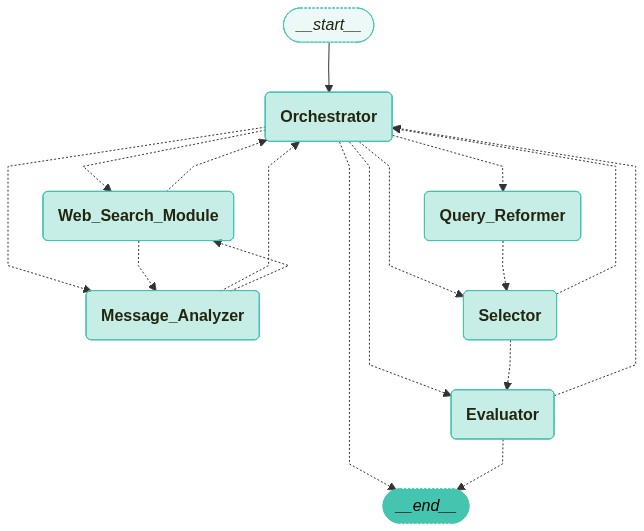

In [41]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(compiled_graph)

그래프 실행 상태 저장을 위한 MemorySaver 설정

thread_id를 통해 하나의 사용자/세션 단위 실행 흐름 구성

재귀 제한(recursion_limit)을 통해 그래프 반복 실행 상한 제어



단일 세션 기준 에이전트 워크플로우 실행 예시

In [42]:
memory = MemorySaver()

config1 = RunnableConfig(
    recursion_limit=20,
    configurable={"thread_id": "1"},
)
compiled_graph = graph.compile(checkpointer=memory)
input_message = df.iloc[0, 1]
username = df.iloc[0, 0]
initial_state = get_initial_state(input_message, username)

compiled_graph.invoke(initial_state, config=config1)

content="메시지에서 '평일 낮 책 읽기'라는 활동과 '양재동, 포이동, 양재천 카페거리'라는 장소가 언급되었으며, 독서하기 편안한 카페에서 각자 읽고 싶은 책을 읽는 모임을 찾고 있습니다. 이는 독서 모임의 일종으로 볼 수 있습니다. 메시지의 목적과 대상이 명확하지 않으므로, Message Analyzer를 호출하여 메시지의 세부 목적과 대상을 명확히 파악할 필요가 있습니다.\n메시지의 세부 목적과 대상을 명확히 파악하여 매칭에 필요한 정보를 추출한다." additional_kwargs={} response_metadata={} name='Orchestrator'
Message_Analyzer
content="메시지는 평일 낮에 양재동, 포이동, 양재천 카페거리에서 독서하기 편안한 카페를 찾고 있으며, 각자 읽고 싶은 책을 읽다가 자유롭게 시간을 보낼 수 있는 사람을 찾고 있다. 이는 독서 모임의 일종으로, 함께 독서를 즐길 수 있는 '독서 친구'를 찾는 것으로 해석할 수 있다. 따라서 매칭 대상은 '독서 친구'로 설정하는 것이 적절하다.\n매칭 대상이 '독서 친구'로 설정되었으므로, 이를 기반으로 매칭 프로세스를 진행한다." additional_kwargs={} response_metadata={} name='Message_Analyzer'
Orchestrator
content="현재 메시지는 '독서 친구'를 찾는 것으로 해석되었으며, 이는 독서 모임의 일종으로 볼 수 있습니다. 따라서, 이 정보를 바탕으로 적합한 매칭 대상을 찾기 위해 Query Reformer를 호출하여 의미 기반 후보 쿼리를 구성하고자 합니다. 이는 이후 Selector를 통해 최적의 매칭 대상을 선별하기 위한 준비 단계입니다.\n독서 친구를 찾기 위한 의미 기반 후보 쿼리를 구성한다." additional_kwargs={} response_metadata={} name='Orchestrator'
Query_Reformer
content="Reformed Queries - 독서 

{'input_message': '평일 낮 책 읽기    양재동, 포이동, 양재천 카페거리  에 독서하기 편안한 카페에서  각자 읽고 읽고 싶은 책 읽다가 편안한 시간에 자유롭게 가실 분   ',
 'username': '린우',
 'count': 7,
 'evaluation_count': 2,
 'hypernym': '독서 모임',
 'matching_target': '독서 친구',
 'matched_message': '카페가서 같이 책읽으며 대화할 친구 있으려나 SF 소설이나 철학책 읽는 것 좋아하는 23 남인데 뭔가 독서토론 모임 이런건 좀 부담스러워서',
 'matched_username': '하와이안',
 'certainty': 75,
 'messages': "1) 매칭 적합도 판단\n   1-1) Matching_target 혹은 상위어와의 유사성: 사용자는 '독서 친구'를 찾고 있으며, 하와이안도 카페에서 책을 읽으며 대화할 친구를 찾고 있어 Matching_target이 유사하다.\n   1-2) 역할 상보성: 사용자는 편안하게 각자 책을 읽고 자유롭게 시간을 보내고자 하며, 하와이안은 독서토론 모임은 부담스러워하지만 책을 읽으며 대화할 친구를 찾고 있어 상보성이 있다.\n   1-3) type 일치도: 둘 다 사람(HUMAN)으로 type이 일치한다.\n   1-4) persona 일치도: 사용자는 자유롭고 편안한 독서 환경을 원하며, 하와이안도 독서토론 모임은 부담스러워하지만 편안한 독서 환경을 원한다.\n2) 지금이 첫 번째 판단분기이며, 확신 정도가 75로 80에 미치지 못하지만, 상보성과 Matching_target 유사성이 높아 success로 판단한다.\n__end__",
 'last_agent': 'Evaluator',
 'next_agent': '__end__',
 'analyzed_message': "메시지는 평일 낮에 양재동, 포이동, 양재천 카페거리에서 독서하기 편안한 카페를 찾고 있으며, 각자 읽고 싶은 책을 읽다가 자유롭